In [1]:
import numpy as np
print(np.__version__)

import torch
print(torch.__version__)

torch.manual_seed(0)

2.2.3
2.14.0+cu126


0.9749353528022766
-1
[[ 1  1 -1]
 [ 1  0  0]
 [ 0  0 -1]]
tensor([[[[1., 1., 0.],
          [1., 0., 0.],
          [0., 0., 0.]],

         [[0., 0., 0.],
          [0., 1., 1.],
          [1., 1., 0.]],

         [[0., 0., 1.],
          [0., 0., 0.],
          [0., 0., 1.]]]], device='cuda:0')


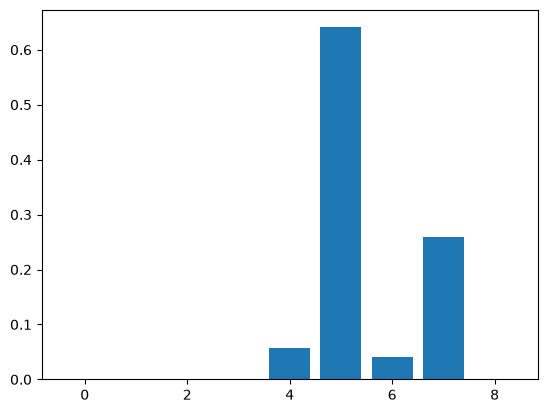

In [2]:
import matplotlib.pyplot as plt
from alphazero.games.TicTacToe import TicTacToeGame
from alphazero.models.model import ResNet

game = TicTacToeGame()
game.make_move(0)
game.make_move(2)
game.make_move(3)
game.make_move(8)
game.make_move(1)

tensor_state = game.neutral_state().to_tensor().unsqueeze(0).to("cuda").to(torch.float32)

model_args = {
    "game_type": game,
    "num_resBlocks": 3,
    "num_channels": 32,
    "head_hidden_size": 16,
    "device": "cpu",
    "batch_size": 1,
    "state_dict": None,
    }

model = ResNet(**model_args)
model.load_state_dict(torch.load('../artifacts/tictactoe_r40_p4_gw32_gpw32_b64_e4/model_004.pt'))
model.to("cuda")
model.eval()

policy, value = model(tensor_state)
value = value.item()
policy = torch.softmax(policy, dim=1).squeeze(0).detach().cpu().numpy()

print(value)

print(game.current_player)
print(game.state)
print(tensor_state)

plt.bar(range(game.action_size), policy)
plt.show()

0.9455823021950108


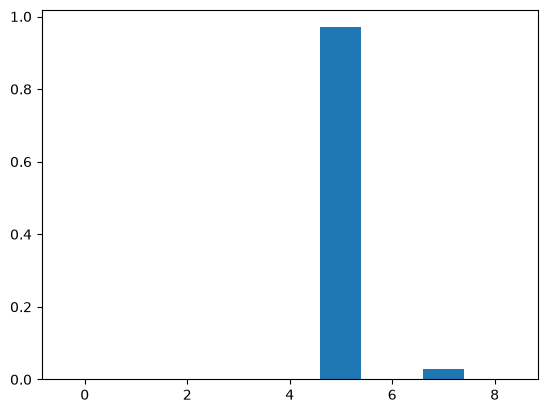

In [3]:
from alphazero.MCTS.MCTS_AlphaZero import MCTS_Factory

factory = MCTS_Factory(100)
mcts = factory.make_instance(game=game)
action_probs, value = mcts.search(model)

print(value)
plt.bar(range(game.action_size), action_probs)
plt.show()